In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,RobustScaler,OneHotEncoder
from sklearn.linear_model import LinearRegression
import pickle
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
import warnings
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv("/kaggle/input/datasets/mohamedesam10/cars-price-dataset/CarPrice_Assignment.csv.xls")
df

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,201,-1,volvo 145e (sw),gas,std,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,9.5,114,5400,23,28,16845.0
201,202,-1,volvo 144ea,gas,turbo,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,8.7,160,5300,19,25,19045.0
202,203,-1,volvo 244dl,gas,std,four,sedan,rwd,front,109.1,...,173,mpfi,3.58,2.87,8.8,134,5500,18,23,21485.0
203,204,-1,volvo 246,diesel,turbo,four,sedan,rwd,front,109.1,...,145,idi,3.01,3.40,23.0,106,4800,26,27,22470.0


<h1 style="color:purple">EDA & Cleaning</h1>

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    object 
 3   fueltype          205 non-null    object 
 4   aspiration        205 non-null    object 
 5   doornumber        205 non-null    object 
 6   carbody           205 non-null    object 
 7   drivewheel        205 non-null    object 
 8   enginelocation    205 non-null    object 
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    object 
 15  cylindernumber    205 non-null    object 
 16  enginesize        205 non-null    int64  
 1

In [4]:
df.describe(include='all')

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
count,205.000000,205.000000,205,205,205,205,205,205,205,205.000000,...,205.000000,205,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
unique,NaN,NaN,147,2,2,2,5,3,2,NaN,...,NaN,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,peugeot 504,gas,std,four,sedan,fwd,front,NaN,...,NaN,mpfi,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,6,185,168,115,96,120,202,NaN,...,NaN,94,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,103.000000,0.834146,NaN,NaN,NaN,NaN,NaN,NaN,NaN,98.756585,...,126.907317,NaN,3.329756,3.255415,10.142537,104.117073,5125.121951,25.219512,30.751220,13276.710571
std,59.322565,1.245307,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.021776,...,41.642693,NaN,0.270844,0.313597,3.972040,39.544167,476.985643,6.542142,6.886443,7988.852332
min,1.000000,-2.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,86.600000,...,61.000000,NaN,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,52.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,94.500000,...,97.000000,NaN,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7788.000000
50%,103.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,97.000000,...,120.000000,NaN,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10295.000000
75%,154.000000,2.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,102.400000,...,141.000000,NaN,3.580000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16503.000000


| Column               | Short Description                          | How It Affects Price                                                                    |
| -------------------- | ------------------------------------------ | --------------------------------------------------------------------------------------- |
| **car_ID**           | Unique ID for each car                     | Does not affect price; used only for identification.                                    |
| **symboling**        | Risk rating of the car                     | Higher risk cars are often sportier, which can increase price.                          |
| **CarName**          | Brand and model name                       | Brand reputation strongly influences price (luxury brands cost more).                   |
| **fueltype**         | Type of fuel used                          | Diesel cars can cost more due to fuel efficiency and durability.                        |
| **aspiration**       | Engine air intake type (standard or turbo) | Turbocharged engines usually increase price because they provide more power.            |
| **doornumber**       | Number of doors                            | Four-door cars may cost more due to practicality, but impact is usually small.          |
| **carbody**          | Vehicle body style                         | Convertibles and sports styles typically cost more than sedans or hatchbacks.           |
| **drivewheel**       | Wheels powered by the engine               | Rear-wheel and four-wheel drive systems often increase price due to better performance. |
| **enginelocation**   | Engine position in the car                 | Rear-engine cars are less common and often more expensive.                              |
| **wheelbase**        | Distance between front and rear wheels     | Longer wheelbases usually mean more interior space and comfort, increasing price.       |
| **carlength**        | Total vehicle length                       | Longer cars are often associated with larger, more premium vehicles.                    |
| **carwidth**         | Width of the car                           | Wider cars typically provide more stability and interior room, raising price.           |
| **carheight**        | Height of the vehicle                      | Taller cars may offer more headroom but generally have a smaller effect on price.       |
| **curbweight**       | Weight of the car without passengers       | Heavier cars often include larger engines and more features, increasing price.          |
| **enginetype**       | Engine design configuration                | More advanced engine designs usually cost more to manufacture, raising price.           |
| **cylindernumber**   | Number of engine cylinders                 | More cylinders typically produce more power and increase price.                         |
| **enginesize**       | Engine capacity                            | Larger engines generate more power and significantly increase price.                    |
| **fuelsystem**       | Method of delivering fuel to the engine    | Advanced fuel systems improve performance and can raise price.                          |
| **boreratio**        | Diameter of engine cylinders               | Larger bore sizes can support higher performance, slightly increasing price.            |
| **stroke**           | Piston travel distance                     | Impacts engine performance; effect on price is moderate.                                |
| **compressionratio** | Engine compression efficiency              | Higher ratios improve efficiency and performance, sometimes increasing price.           |
| **horsepower**       | Engine power output                        | Cars with higher horsepower are typically more expensive.                               |
| **peakrpm**          | RPM at maximum power                       | Higher peak performance can contribute to a higher price.                               |
| **citympg**          | Fuel efficiency in city driving            | Higher fuel efficiency can make cars more attractive, affecting price positively.       |
| **highwaympg**       | Fuel efficiency on highways                | Better efficiency can increase value, especially for long-distance drivers.             |
| **price**            | Vehicle selling price                      | The final cost of the car influenced by its features, performance, and brand.           |


In [5]:
lis=['CarName','fueltype','aspiration','doornumber','carbody','drivewheel','enginelocation','enginetype','cylindernumber','fuelsystem']

In [6]:
for i in lis:
    print(df[i].value_counts())
    print('-------------')

CarName
peugeot 504                 6
toyota corolla              6
toyota corona               6
subaru dl                   4
mitsubishi outlander        3
                           ..
volkswagen super beetle     1
volkswagen rabbit custom    1
volvo 245                   1
volvo diesel                1
volvo 246                   1
Name: count, Length: 147, dtype: int64
-------------
fueltype
gas       185
diesel     20
Name: count, dtype: int64
-------------
aspiration
std      168
turbo     37
Name: count, dtype: int64
-------------
doornumber
four    115
two      90
Name: count, dtype: int64
-------------
carbody
sedan          96
hatchback      70
wagon          25
hardtop         8
convertible     6
Name: count, dtype: int64
-------------
drivewheel
fwd    120
rwd     76
4wd      9
Name: count, dtype: int64
-------------
enginelocation
front    202
rear       3
Name: count, dtype: int64
-------------
enginetype
ohc      148
ohcf      15
ohcv      13
dohc      12
l         12
r

In [7]:
df[df['enginelocation']=='rear']

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
126,127,3,porcshce panamera,gas,std,two,hardtop,rwd,rear,89.5,...,194,mpfi,3.74,2.9,9.5,207,5900,17,25,32528.0
127,128,3,porsche cayenne,gas,std,two,hardtop,rwd,rear,89.5,...,194,mpfi,3.74,2.9,9.5,207,5900,17,25,34028.0
128,129,3,porsche boxter,gas,std,two,convertible,rwd,rear,89.5,...,194,mpfi,3.74,2.9,9.5,207,5900,17,25,37028.0


In [8]:
counts = df['fuelsystem'].value_counts()
counts

fuelsystem
mpfi    94
2bbl    66
idi     20
1bbl    11
spdi     9
4bbl     3
mfi      1
spfi     1
Name: count, dtype: int64

In [9]:
rare = counts[counts < 5].index
rare

Index(['4bbl', 'mfi', 'spfi'], dtype='object', name='fuelsystem')

In [10]:
df['fuelsystem'] = df['fuelsystem'].replace(rare, 'other')

In [11]:
pd.set_option('display.max_rows', None)

In [12]:
for i in lis:
    print(df[i].value_counts())
    print('-------------')

CarName
peugeot 504                        6
toyota corolla                     6
toyota corona                      6
subaru dl                          4
mitsubishi outlander               3
mazda 626                          3
honda civic                        3
mitsubishi mirage g4               3
mitsubishi g4                      3
toyota mark ii                     3
nissan clipper                     2
honda civic cvcc                   2
honda accord                       2
mazda glc                          2
mazda rx-7 gs                      2
mazda glc deluxe                   2
bmw x3                             2
bmw 320i                           2
audi 100ls                         2
volvo 264gl                        2
volvo 144ea                        2
volvo 244dl                        2
toyota starlet                     2
volvo 145e (sw)                    2
subaru                             2
toyota corolla 1200                2
saab 99e                      

In [13]:
pd.reset_option("all")

In [14]:
df['brand'] = df['CarName'].str.split().str[0]

In [15]:
df

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price,brand
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0,alfa-romero
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0,alfa-romero
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0,alfa-romero
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0,audi
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0,audi
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,201,-1,volvo 145e (sw),gas,std,four,sedan,rwd,front,109.1,...,mpfi,3.78,3.15,9.5,114,5400,23,28,16845.0,volvo
201,202,-1,volvo 144ea,gas,turbo,four,sedan,rwd,front,109.1,...,mpfi,3.78,3.15,8.7,160,5300,19,25,19045.0,volvo
202,203,-1,volvo 244dl,gas,std,four,sedan,rwd,front,109.1,...,mpfi,3.58,2.87,8.8,134,5500,18,23,21485.0,volvo
203,204,-1,volvo 246,diesel,turbo,four,sedan,rwd,front,109.1,...,idi,3.01,3.40,23.0,106,4800,26,27,22470.0,volvo


In [16]:
df['brand'] = df['brand'].replace({
    'toyouta':'toyota',
    'vokswagen':'volkswagen',
    'vw':'volkswagen',
    'maxda':'mazda',
    'porcshce':'porsche'
})
df

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price,brand
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0,alfa-romero
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0,alfa-romero
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0,alfa-romero
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0,audi
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0,audi
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,201,-1,volvo 145e (sw),gas,std,four,sedan,rwd,front,109.1,...,mpfi,3.78,3.15,9.5,114,5400,23,28,16845.0,volvo
201,202,-1,volvo 144ea,gas,turbo,four,sedan,rwd,front,109.1,...,mpfi,3.78,3.15,8.7,160,5300,19,25,19045.0,volvo
202,203,-1,volvo 244dl,gas,std,four,sedan,rwd,front,109.1,...,mpfi,3.58,2.87,8.8,134,5500,18,23,21485.0,volvo
203,204,-1,volvo 246,diesel,turbo,four,sedan,rwd,front,109.1,...,idi,3.01,3.40,23.0,106,4800,26,27,22470.0,volvo


In [17]:
df.drop(['CarName','car_ID'],axis=1,inplace=True)

<h1 style="color:purple">Visualization</h1>

In [18]:
df

,symboling,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,carwidth,...,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price,brand
0,3,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,...,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0,alfa-romero
1,3,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,...,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0,alfa-romero
2,1,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,...,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0,alfa-romero
3,2,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,...,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0,audi
4,2,gas,std,four,sedan,4wd,front,99.4,176.6,66.4,...,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0,audi
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,-1,gas,std,four,sedan,rwd,front,109.1,188.8,68.9,...,mpfi,3.78,3.15,9.5,114,5400,23,28,16845.0,volvo
201,-1,gas,turbo,four,sedan,rwd,front,109.1,188.8,68.8,...,mpfi,3.78,3.15,8.7,160,5300,19,25,19045.0,volvo
202,-1,gas,std,four,sedan,rwd,front,109.1,188.8,68.9,...,mpfi,3.58,2.87,8.8,134,5500,18,23,21485.0,volvo
203,-1,diesel,turbo,four,sedan,rwd,front,109.1,188.8,68.9,...,idi,3.01,3.40,23.0,106,4800,26,27,22470.0,volvo


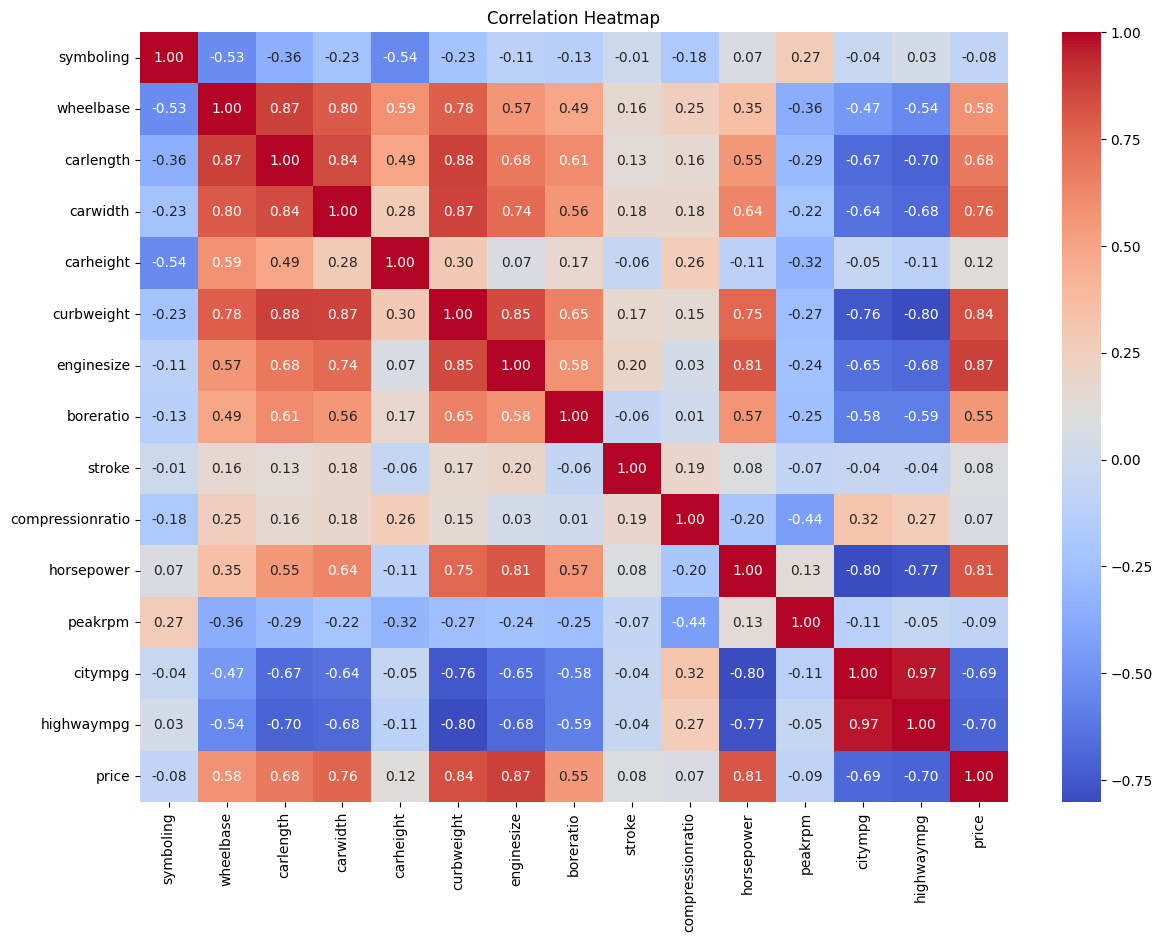

In [19]:
plt.figure(figsize=(14,10))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()


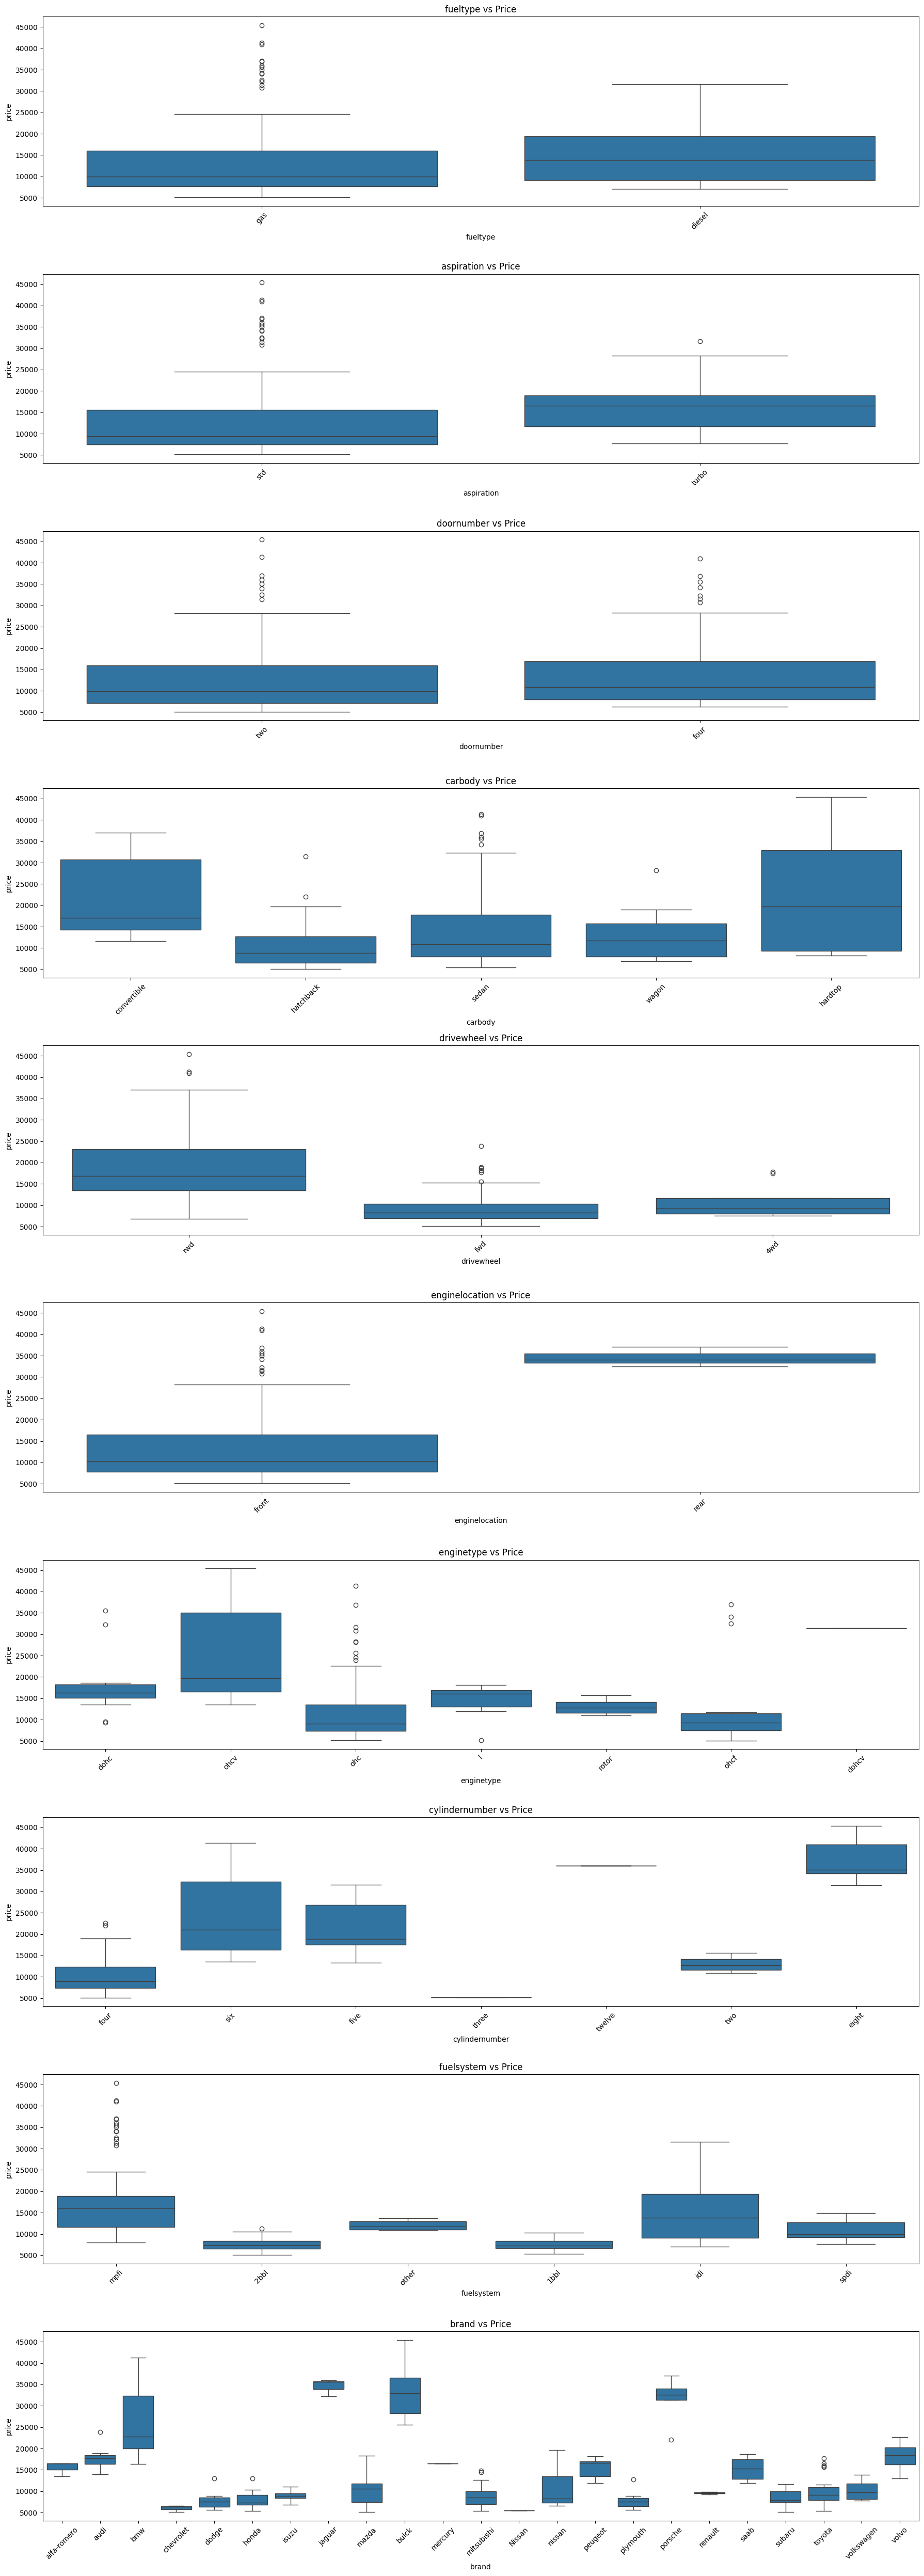

In [20]:
cat_cols = df.select_dtypes(include='object').columns

plt.figure(figsize=(18, 5 * len(cat_cols)))

for i, col in enumerate(cat_cols, 1):
    plt.subplot(len(cat_cols), 1, i)
    sns.boxplot(x=col, y='price', data=df)
    plt.title(f'{col} vs Price')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

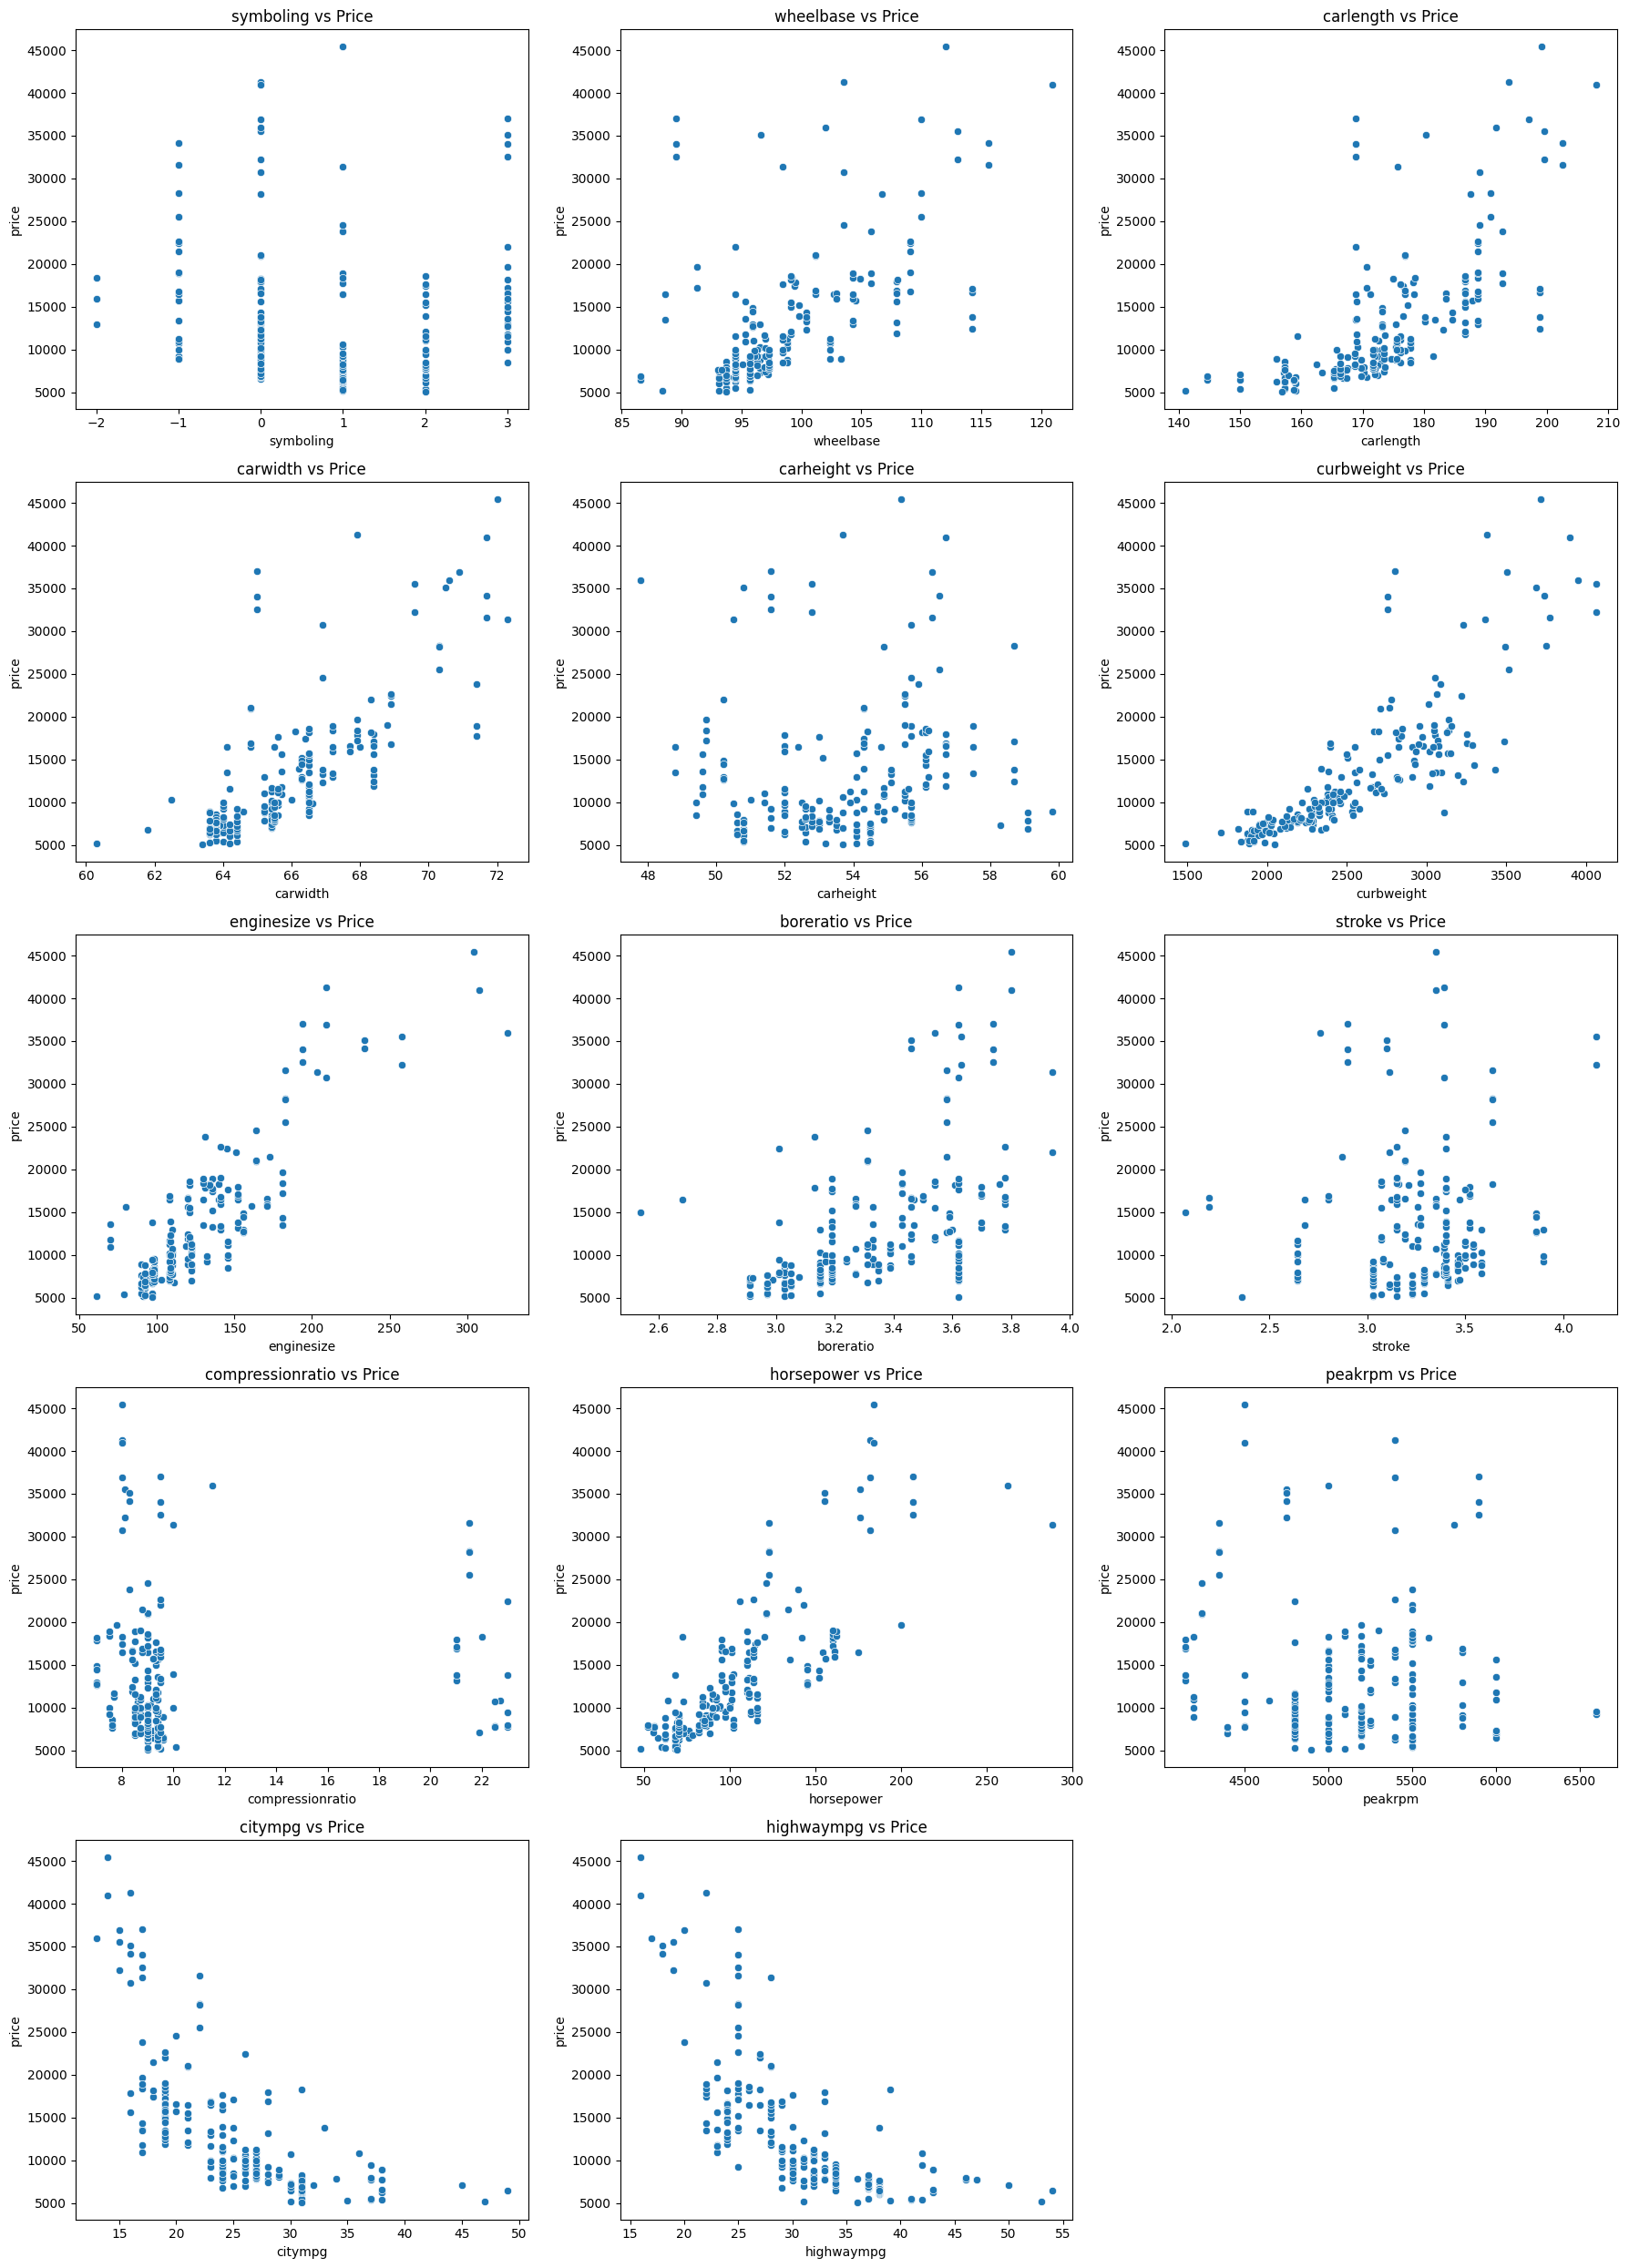

In [21]:
num_cols = df.select_dtypes(include=['int64','float64']).columns
num_cols = num_cols.drop('price')
n_cols = 3
n_rows = (len(num_cols) // n_cols) + 1

plt.figure(figsize=(18, 5*n_rows))

for i, col in enumerate(num_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.scatterplot(x=df[col], y=df['price'])
    plt.title(f'{col} vs Price')

plt.tight_layout()
plt.show()

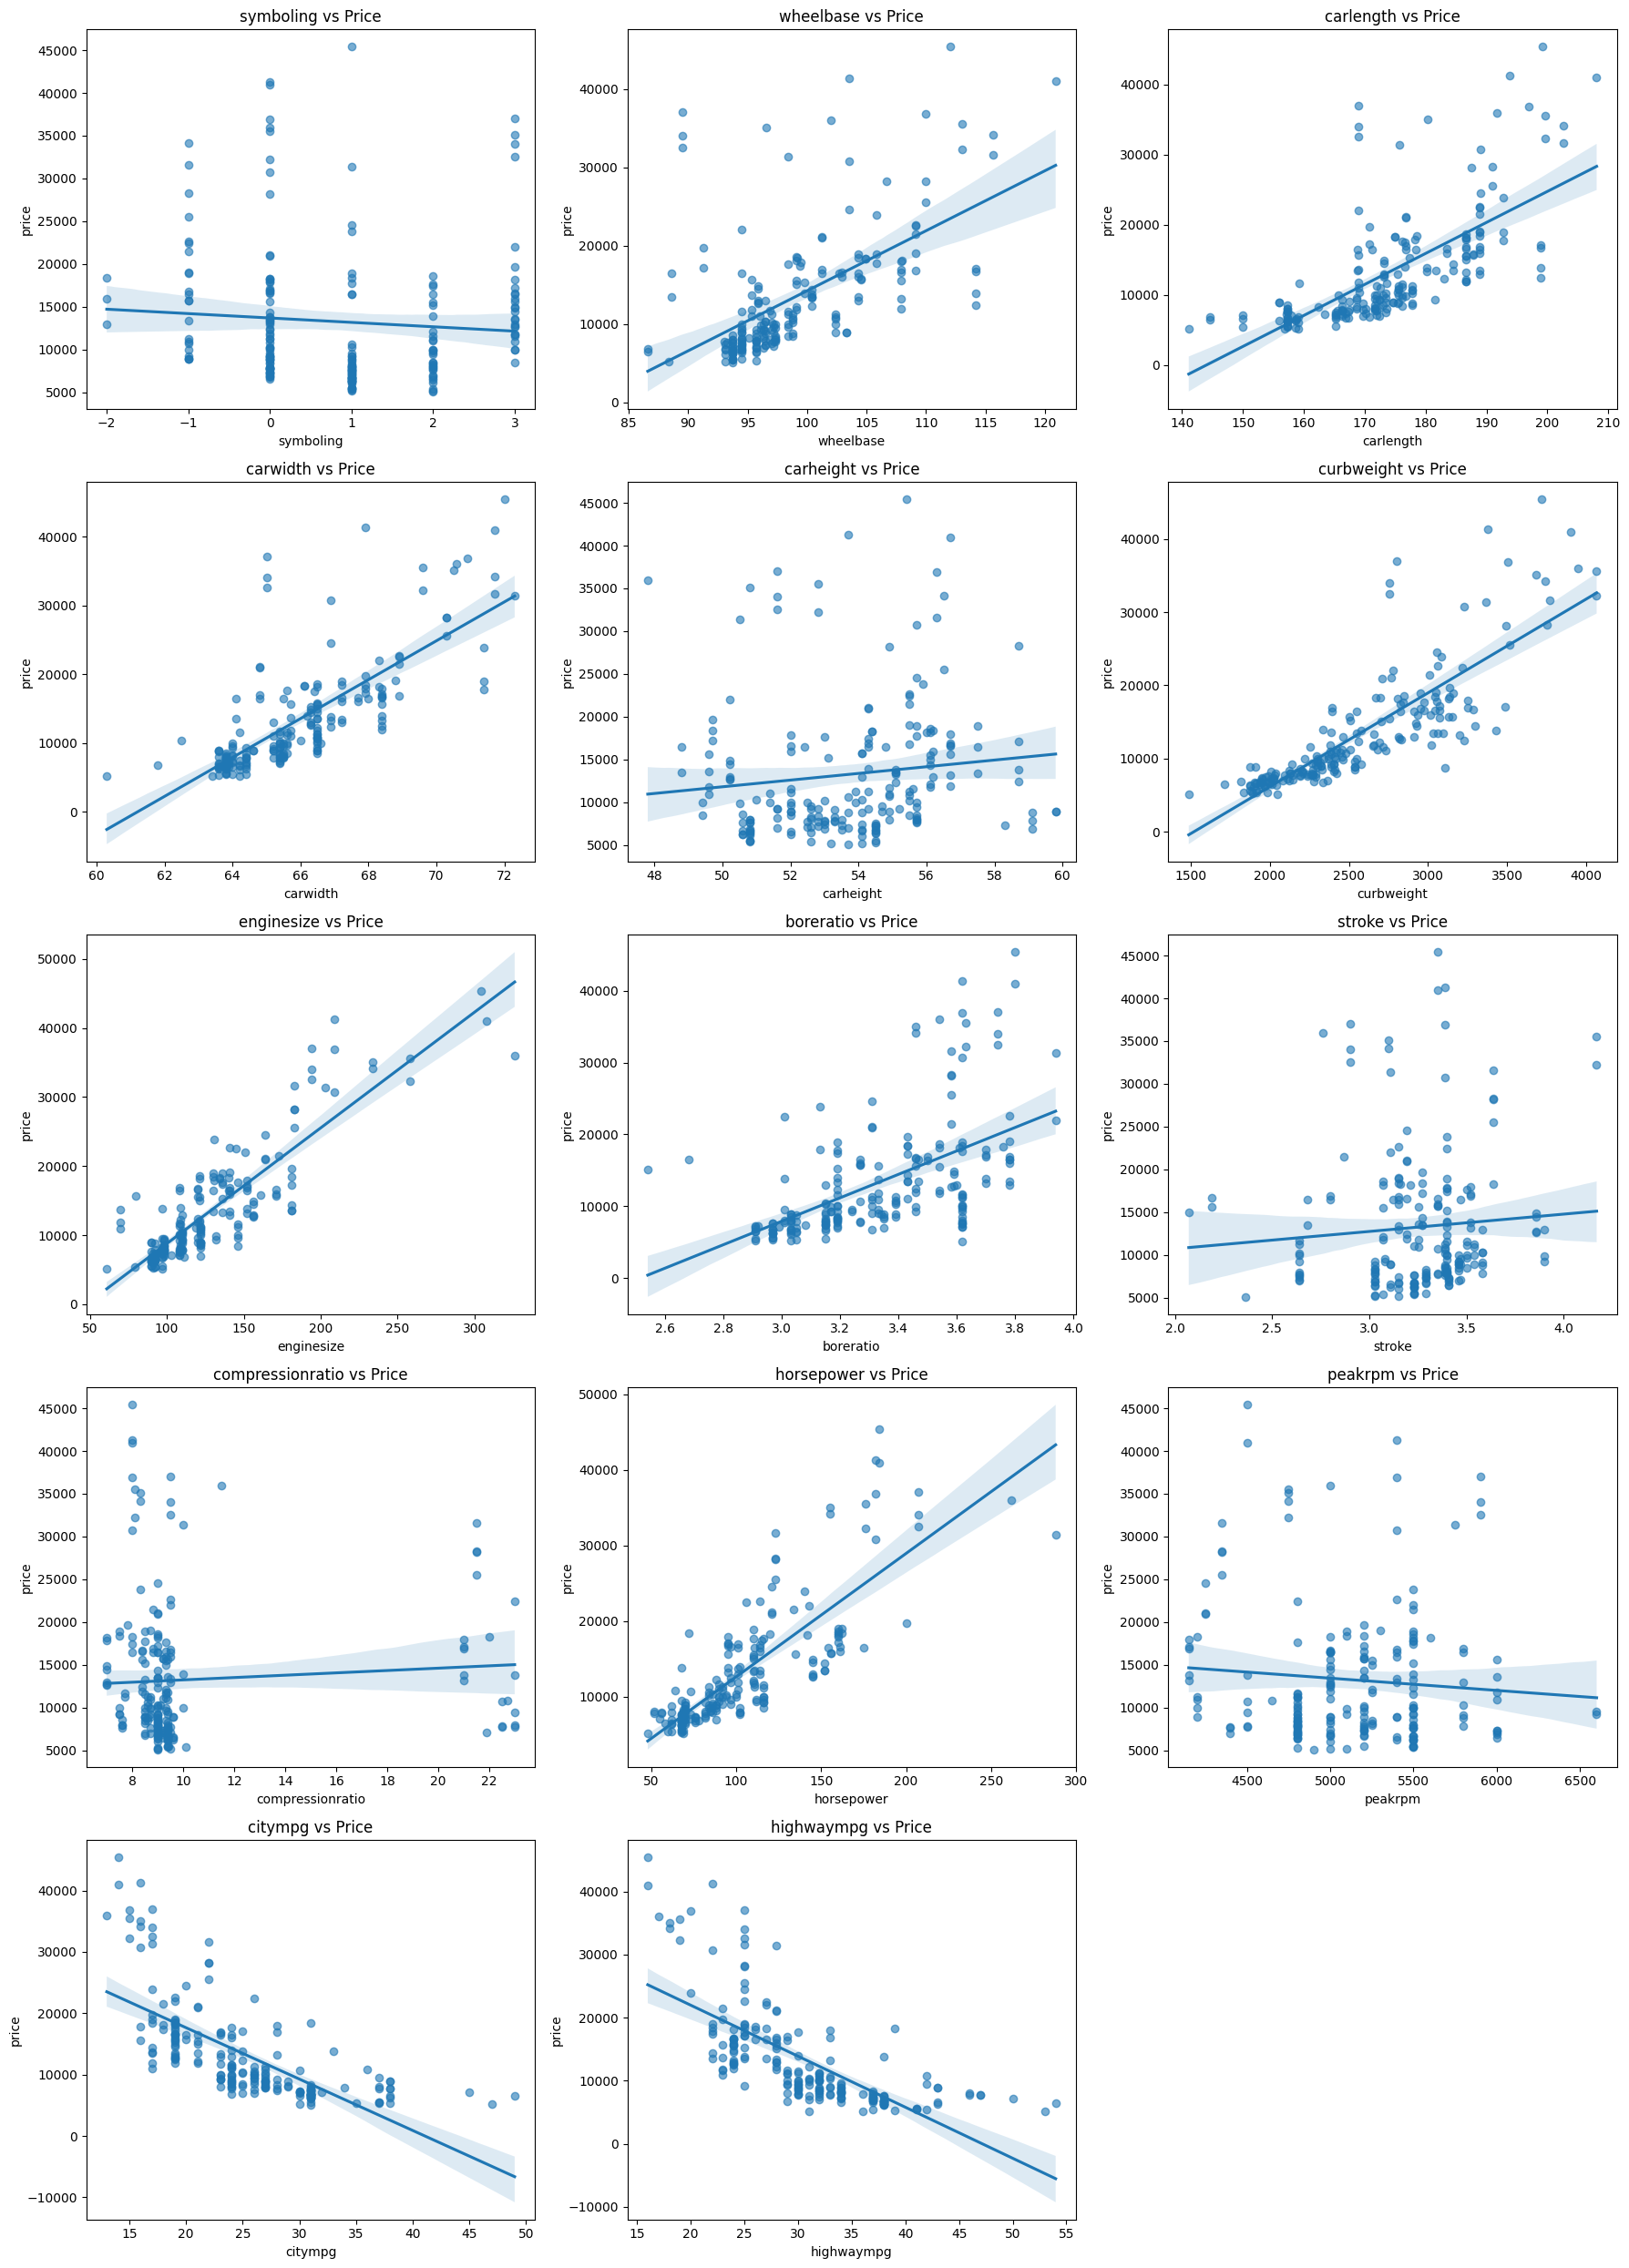

In [22]:
plt.figure(figsize=(18, 5*n_rows))

for i, col in enumerate(num_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.regplot(x=df[col], y=df['price'], scatter_kws={'alpha':0.6})
    plt.title(f'{col} vs Price')

plt.tight_layout()
plt.show()


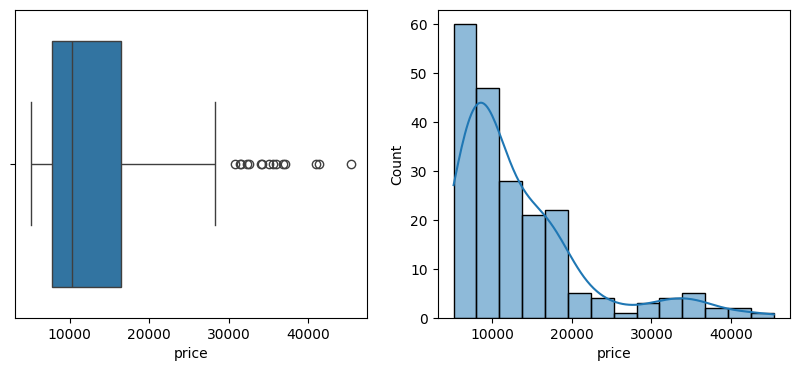

In [23]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.boxplot(x=df['price'])

plt.subplot(1,2,2)
sns.histplot(df['price'], kde=True)

plt.show()


In [24]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)

IQR = Q3 - Q1

In [25]:
df[df['price'] > (Q3 + 1.5 * IQR)]

,symboling,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,carwidth,...,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price,brand
15,0,gas,std,four,sedan,rwd,front,103.5,189.0,66.9,...,mpfi,3.62,3.39,8.0,182,5400,16,22,30760.0,bmw
16,0,gas,std,two,sedan,rwd,front,103.5,193.8,67.9,...,mpfi,3.62,3.39,8.0,182,5400,16,22,41315.0,bmw
17,0,gas,std,four,sedan,rwd,front,110.0,197.0,70.9,...,mpfi,3.62,3.39,8.0,182,5400,15,20,36880.0,bmw
47,0,gas,std,four,sedan,rwd,front,113.0,199.6,69.6,...,mpfi,3.63,4.17,8.1,176,4750,15,19,32250.0,jaguar
48,0,gas,std,four,sedan,rwd,front,113.0,199.6,69.6,...,mpfi,3.63,4.17,8.1,176,4750,15,19,35550.0,jaguar
49,0,gas,std,two,sedan,rwd,front,102.0,191.7,70.6,...,mpfi,3.54,2.76,11.5,262,5000,13,17,36000.0,jaguar
70,-1,diesel,turbo,four,sedan,rwd,front,115.6,202.6,71.7,...,idi,3.58,3.64,21.5,123,4350,22,25,31600.0,buick
71,-1,gas,std,four,sedan,rwd,front,115.6,202.6,71.7,...,mpfi,3.46,3.10,8.3,155,4750,16,18,34184.0,buick
72,3,gas,std,two,convertible,rwd,front,96.6,180.3,70.5,...,mpfi,3.46,3.10,8.3,155,4750,16,18,35056.0,buick
73,0,gas,std,four,sedan,rwd,front,120.9,208.1,71.7,...,mpfi,3.80,3.35,8.0,184,4500,14,16,40960.0,buick


In [26]:
df['log_price'] = np.log(df['price'])

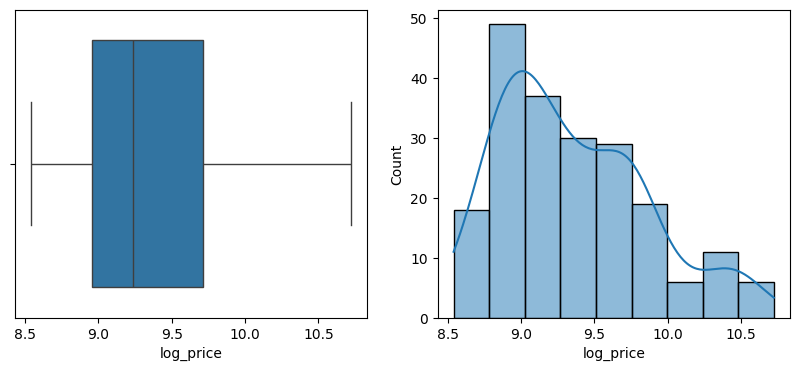

In [27]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.boxplot(x=df['log_price'])

plt.subplot(1,2,2)
sns.histplot(df['log_price'], kde=True)

plt.show()


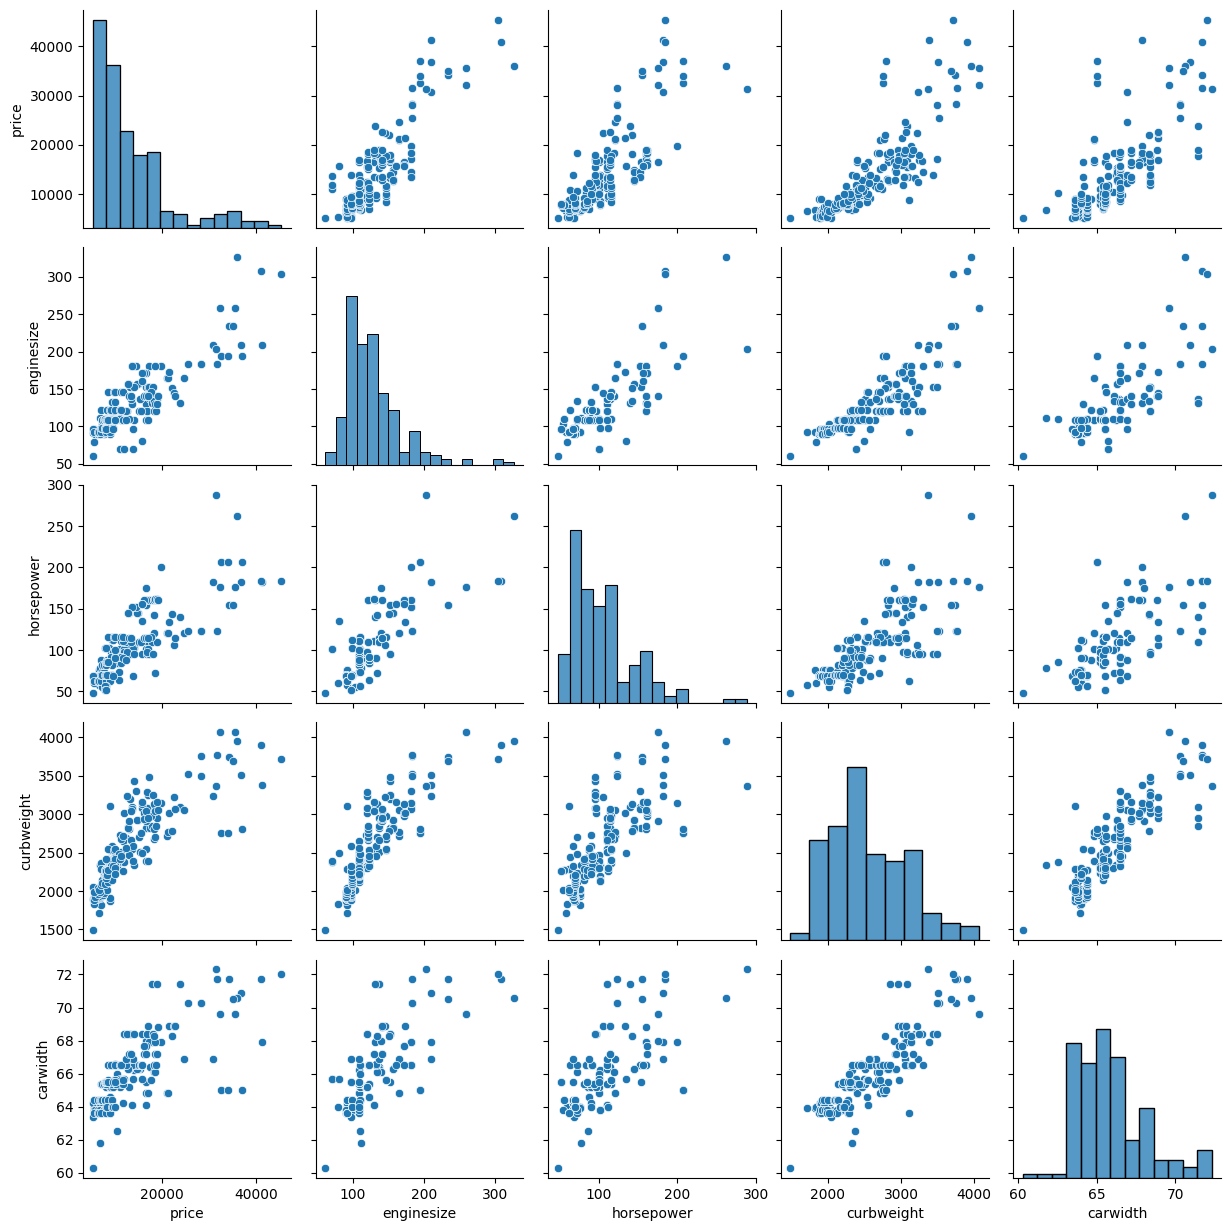

In [28]:
sns.pairplot(
    df[['price','enginesize','horsepower','curbweight','carwidth']]
)
plt.show()


In [29]:
df

,symboling,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,carwidth,...,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price,brand,log_price
0,3,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,...,3.47,2.68,9.0,111,5000,21,27,13495.0,alfa-romero,9.510075
1,3,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,...,3.47,2.68,9.0,111,5000,21,27,16500.0,alfa-romero,9.711116
2,1,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,...,2.68,3.47,9.0,154,5000,19,26,16500.0,alfa-romero,9.711116
3,2,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,...,3.19,3.40,10.0,102,5500,24,30,13950.0,audi,9.543235
4,2,gas,std,four,sedan,4wd,front,99.4,176.6,66.4,...,3.19,3.40,8.0,115,5500,18,22,17450.0,audi,9.767095
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,-1,gas,std,four,sedan,rwd,front,109.1,188.8,68.9,...,3.78,3.15,9.5,114,5400,23,28,16845.0,volvo,9.731809
201,-1,gas,turbo,four,sedan,rwd,front,109.1,188.8,68.8,...,3.78,3.15,8.7,160,5300,19,25,19045.0,volvo,9.854560
202,-1,gas,std,four,sedan,rwd,front,109.1,188.8,68.9,...,3.58,2.87,8.8,134,5500,18,23,21485.0,volvo,9.975110
203,-1,diesel,turbo,four,sedan,rwd,front,109.1,188.8,68.9,...,3.01,3.40,23.0,106,4800,26,27,22470.0,volvo,10.019936


<h1 style='color:purple'>Encoding</h1>

In [30]:
df['mpg_avg'] = (df['citympg'] + df['highwaympg'])/2
df.drop(['citympg','highwaympg'], axis=1, inplace=True)

In [31]:
cyl_map = {
'two':2, 'three':3, 'four':4,
'five':5, 'six':6, 'eight':8,
'twelve':12
}

df['cylindernumber'] = df['cylindernumber'].map(cyl_map)

In [32]:
df = pd.get_dummies(df, drop_first=True)

In [33]:
df

,symboling,wheelbase,carlength,carwidth,carheight,curbweight,cylindernumber,enginesize,boreratio,stroke,...,brand_nissan,brand_peugeot,brand_plymouth,brand_porsche,brand_renault,brand_saab,brand_subaru,brand_toyota,brand_volkswagen,brand_volvo
0,3,88.6,168.8,64.1,48.8,2548,4,130,3.47,2.68,...,False,False,False,False,False,False,False,False,False,False
1,3,88.6,168.8,64.1,48.8,2548,4,130,3.47,2.68,...,False,False,False,False,False,False,False,False,False,False
2,1,94.5,171.2,65.5,52.4,2823,6,152,2.68,3.47,...,False,False,False,False,False,False,False,False,False,False
3,2,99.8,176.6,66.2,54.3,2337,4,109,3.19,3.40,...,False,False,False,False,False,False,False,False,False,False
4,2,99.4,176.6,66.4,54.3,2824,5,136,3.19,3.40,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,-1,109.1,188.8,68.9,55.5,2952,4,141,3.78,3.15,...,False,False,False,False,False,False,False,False,False,True
201,-1,109.1,188.8,68.8,55.5,3049,4,141,3.78,3.15,...,False,False,False,False,False,False,False,False,False,True
202,-1,109.1,188.8,68.9,55.5,3012,6,173,3.58,2.87,...,False,False,False,False,False,False,False,False,False,True
203,-1,109.1,188.8,68.9,55.5,3217,6,145,3.01,3.40,...,False,False,False,False,False,False,False,False,False,True


In [34]:
X = df.drop(['price','log_price'], axis=1)
y = df['log_price']
columns = X.columns
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [35]:
scaler = StandardScaler()
# scaler = RobustScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [36]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [37]:
pred = model.predict(X_test)

print("R2:", r2_score(y_test, pred))
print("MAE:", mean_absolute_error(y_test, pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred)))

R2: 0.93830299523251
MAE: 0.10822493458305243
RMSE: 0.12938301996535745


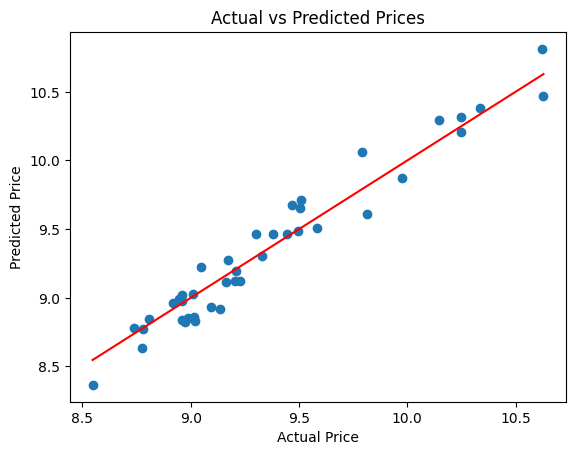

In [38]:
plt.scatter(y_test, pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')

plt.title("Actual vs Predicted Prices")
plt.show()

In [39]:
train_score = model.score(X_train, y_train)
test_score = model.score(X_test, y_test)

In [40]:
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

Text(0.5, 1.0, 'Residual Plot')

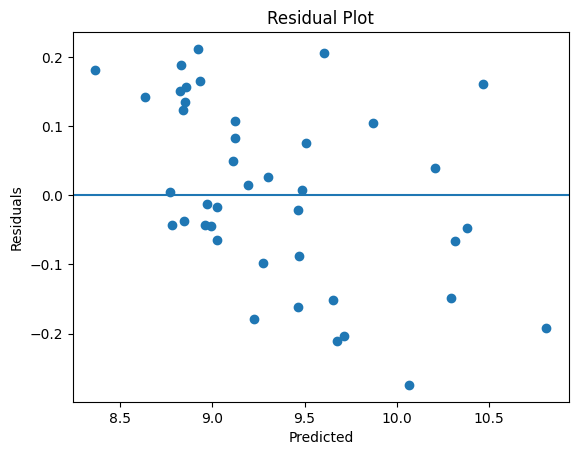

In [41]:
residuals = y_test - pred
plt.scatter(pred, residuals)
plt.axhline(y=0)
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")

In [42]:

print("===== TRAIN METRICS =====")
print("R²:", r2_score(y_train, train_pred))
print("MAE:", mean_absolute_error(y_train, train_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_train, train_pred)))

print("\n===== TEST METRICS =====")
print("R²:", r2_score(y_test, test_pred))
print("MAE:", mean_absolute_error(y_test, test_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, test_pred)))


===== TRAIN METRICS =====
R²: 0.9668072459401794
MAE: 0.07055699796099628
RMSE: 0.09071003454980064

===== TEST METRICS =====
R²: 0.93830299523251
MAE: 0.10822493458305243
RMSE: 0.12938301996535745


In [43]:
real_pred = np.exp(pred)

In [44]:
pickle.dump(model, open("model.pkl", "wb"))
# pickle.dump(scaler, open("scaler.pkl", "wb"))
# pickle.dump(columns, open("columns.pkl", "wb"))